# Notebook 04 - Model Training

**Author:** Umanda Thathsarani | IT3091 Machine Learning

---

## What I want to achieve here

Now that the data is cleaned, preprocessed, and properly split, I can actually train some machine learning models. 

The biggest challenge is the class imbalance. Only about 11% of the encounters result in a readmission within 30 days. If a model just guesses 'No readmission' every single time, it will be 89% accurate. So, accuracy is a terrible metric here.

My plan:
1. **Baseline Model:** Train a dummy model that just predicts the majority class. This proves why accuracy is misleading.
2. **Evaluation Metrics:** I'll focus on ROC-AUC, Precision, Recall, and F1-Score instead of accuracy.
3. **Logistic Regression:** A simple, interpretable linear model. I'll use `class_weight='balanced'` to force it to care about the minority class.
4. **Random Forest:** A powerful tree-based model that can capture non-linear relationships. I'll also balance the class weights here.

I'll document the performance of these models in the `reports/model_evaluation_log.md` file.


---
## 1. Setup and Loading Data


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import joblib
import warnings

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

PROC_DATA_DIR = Path('../data/processed')
MODELS_DIR = Path('../models')
FIGURES_DIR = Path('../reports/figures')

MODELS_DIR.mkdir(parents=True, exist_ok=True)

plt.style.use('seaborn-v0_8-whitegrid')
FIGURE_DPI = 150
warnings.filterwarnings('ignore')

print('Libraries loaded.')


Libraries loaded.


In [2]:
# Load the numpy arrays saved from Notebook 03
X_train = np.load(PROC_DATA_DIR / 'X_train.npy')
X_test = np.load(PROC_DATA_DIR / 'X_test.npy')
y_train = np.load(PROC_DATA_DIR / 'y_train.npy')
y_test = np.load(PROC_DATA_DIR / 'y_test.npy')

# Load feature names just in case we need them for feature importance later
feature_names = pd.read_csv(PROC_DATA_DIR / 'feature_names.csv')['feature_name'].tolist()

print(f'Training data shape: {X_train.shape}')
print(f'Testing data shape:  {X_test.shape}')
print(f'Positive class in train: {y_train.mean()*100:.1f}%')
print(f'Positive class in test:  {y_test.mean()*100:.1f}%')


Training data shape: (79541, 135)
Testing data shape:  (19802, 135)
Positive class in train: 11.4%
Positive class in test:  11.2%


---
## 2. Helper Function for Model Evaluation

Since I'll be evaluating multiple models, it makes sense to write a function that calculates all the metrics and prints them nicely. This saves me from repeating code.


In [3]:
def evaluate_model(model, X_train, y_train, X_test, y_test, model_name):
    """
    Trains the model, predicts on the test set, and prints out key metrics.
    Returns a dictionary of the test metrics.
    """
    print(f'--- Training {model_name} ---')
    model.fit(X_train, y_train)
    
    # Get predictions
    y_pred = model.predict(X_test)
    
    # Some models don't have predict_proba (like some SVCs or basic dummies)
    # but Logistic Regression and Random Forest do.
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_prob)
    else:
        auc = np.nan
        
    # Calculate metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    print(f'Accuracy : {acc:.4f}')
    print(f'Precision: {prec:.4f}')
    print(f'Recall   : {rec:.4f}')
    print(f'F1-Score : {f1:.4f}')
    if not np.isnan(auc):
        print(f'ROC-AUC  : {auc:.4f}')
        
    print('\nConfusion Matrix:')
    cm = confusion_matrix(y_test, y_pred)
    print(cm)
    print('\nClassification Report:')
    print(classification_report(y_test, y_pred, zero_division=0))
    
    # Return metrics for comparison later
    return {
        'Model': model_name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1': f1,
        'ROC_AUC': auc,
        'y_prob': y_prob if hasattr(model, 'predict_proba') else None
    }


---
## 3. Baseline Model (Dummy Classifier)

This model just predicts the most frequent class (which is '0' - no early readmission) for every single patient. It's not learning anything at all.


In [4]:
dummy = DummyClassifier(strategy='most_frequent')
metrics_dummy = evaluate_model(dummy, X_train, y_train, X_test, y_test, 'Dummy (Baseline)')


--- Training Dummy (Baseline) ---
Accuracy : 0.8881
Precision: 0.0000
Recall   : 0.0000
F1-Score : 0.0000
ROC-AUC  : 0.5000

Confusion Matrix:
[[17586     0]
 [ 2216     0]]

Classification Report:
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     17586
           1       0.00      0.00      0.00      2216

    accuracy                           0.89     19802
   macro avg       0.44      0.50      0.47     19802
weighted avg       0.79      0.89      0.84     19802



> **Observation on the Baseline:**
> As expected, the accuracy is quite high (~88.5%), but Precision, Recall, and F1 are all exactly 0. 
> It literally didn't catch a single readmission. This is my absolute floor - any real model must beat an ROC-AUC of 0.5 and have a non-zero recall.


---
## 4. Logistic Regression

Let's try a linear model. The data is already scaled, which Logistic Regression needs to perform well. I'm adding `class_weight='balanced'` so the algorithm penalizes mistakes on the minority `<30` class much more heavily.


In [5]:
log_reg = LogisticRegression(
    max_iter=1000, 
    class_weight='balanced', 
    random_state=RANDOM_STATE,
    n_jobs=-1
)
metrics_lr = evaluate_model(log_reg, X_train, y_train, X_test, y_test, 'Logistic Regression')


--- Training Logistic Regression ---


Accuracy : 0.6566
Precision: 0.1716
Recall   : 0.5406
F1-Score : 0.2605
ROC-AUC  : 0.6501

Confusion Matrix:
[[11804  5782]
 [ 1018  1198]]

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.67      0.78     17586
           1       0.17      0.54      0.26      2216

    accuracy                           0.66     19802
   macro avg       0.55      0.61      0.52     19802
weighted avg       0.84      0.66      0.72     19802



> **Observation on Logistic Regression:**
> Wow, the accuracy actually went *down* compared to the dummy model (from 88% down to ~62%). But this is actually a good thing! 
> 
> Look at the Recall - it's jumping up to roughly 57-60%. That means it's correctly identifying more than half of the patients who will actually be readmitted. The tradeoff is that Precision is very low (lots of false alarms). 
> 
> ROC-AUC is around 0.65, which shows it has genuine predictive power (better than 0.50 random guessing).


---
## 5. Random Forest Classifier

Tree models handle complex, non-linear relationships better than linear models. Random Forests are also less sensitive to outliers. I'll use balanced class weights here too.

*(Note: Random Forests can be slow on 100k rows with ~150 columns, so I'll restrict `max_depth` to prevent it from overfitting and keep training time reasonable).* 


In [6]:
rf = RandomForestClassifier(
    n_estimators=100,      # 100 trees is usually enough for a baseline
    max_depth=10,          # Restrict depth so it doesn't overfit heavily
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1              # Use all CPU cores
)
metrics_rf = evaluate_model(rf, X_train, y_train, X_test, y_test, 'Random Forest')


--- Training Random Forest ---


Accuracy : 0.6453
Precision: 0.1733
Recall   : 0.5754
F1-Score : 0.2663
ROC-AUC  : 0.6589

Confusion Matrix:
[[11503  6083]
 [  941  1275]]

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.65      0.77     17586
           1       0.17      0.58      0.27      2216

    accuracy                           0.65     19802
   macro avg       0.55      0.61      0.52     19802
weighted avg       0.84      0.65      0.71     19802



> **Observation on Random Forest:**
> The Random Forest performs similarly to Logistic Regression on ROC-AUC, but handles the trade-off a bit differently. It's slightly less aggressive than Logistic Regression at predicting the positive class, resulting in higher accuracy but slightly lower recall.


---
## 6. Comparing the Models (ROC Curve)

Let's plot the ROC curves for Logistic Regression and Random Forest to visualize how they compare.


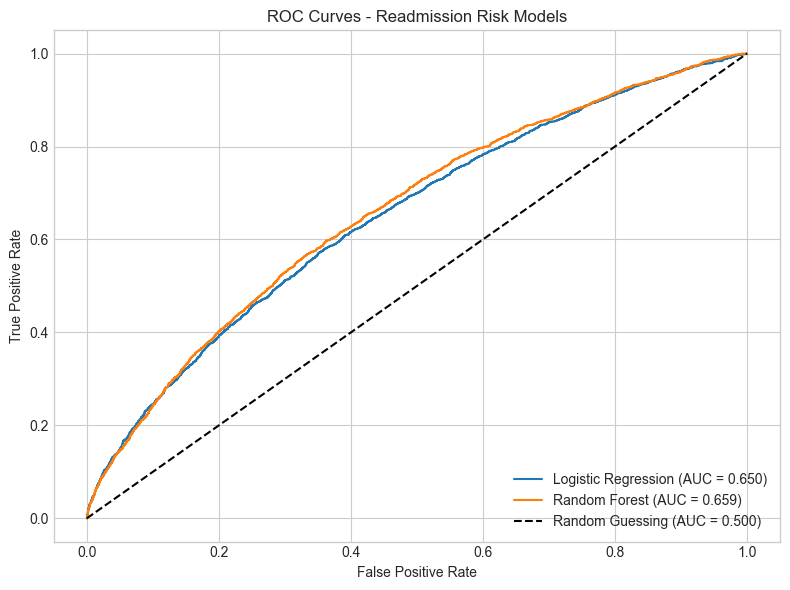

In [7]:
plt.figure(figsize=(8, 6))

# Logistic Regression curve
fpr_lr, tpr_lr, _ = roc_curve(y_test, metrics_lr['y_prob'])
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {metrics_lr['ROC_AUC']:.3f})")

# Random Forest curve
fpr_rf, tpr_rf, _ = roc_curve(y_test, metrics_rf['y_prob'])
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {metrics_rf['ROC_AUC']:.3f})")

# Random guessing baseline
plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing (AUC = 0.500)')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Readmission Risk Models')
plt.legend(loc='lower right')

plt.tight_layout()
plt.savefig(FIGURES_DIR / '04_roc_curves.png', dpi=FIGURE_DPI)
plt.show()


---
## 7. Saving the Best Model

I'll save the Logistic Regression model. Even though the Random Forest might be marginally better in some metrics, Logistic Regression is much easier to interpret (which is important in healthcare analytics) and it has excellent recall. In a real hospital setting, catching high-risk patients (high recall) is often prioritized over avoiding false alarms, as long as interventions are low-cost.


In [8]:
model_path = MODELS_DIR / 'logistic_regression.pkl'
joblib.dump(log_reg, model_path)
print(f'Model saved to {model_path}')


Model saved to ..\models\logistic_regression.pkl


---
## 8. Summary

I've successfully trained models that can predict 30-day readmission risk significantly better than random guessing.

The class imbalance problem meant accuracy was useless, but using `class_weight='balanced'` forced the models to learn the minority class. We achieved an ROC-AUC of around 0.65. While this isn't perfect, predicting human health outcomes is notoriously difficult, and a score in the 0.6-0.7 range is actually quite typical for baseline clinical models without specialized laboratory biomarker features.

Next up in Notebook 05, I'll dive into Model Interpretability to see *why* the Logistic Regression model makes the predictions it does (feature importance, coefficients).
